# 02 — Entraînement du modèle de classification

**Entrée :** `data/processed/Avis_client_processed.csv` (produit par notebook 01)

**Sortie :** trois artefacts dans `models/`
- `tfidf_vectorizer.joblib`
- `label_encoder.joblib`
- `sentiment_classifier.joblib`

**Pipeline :**
1. Chargement du fichier processé
2. Encodage des labels
3. Vectorisation TF-IDF sur `processed_avis`
4. Entraînement et comparaison de 3 classifieurs
5. Évaluation détaillée du meilleur modèle
6. Sauvegarde des artefacts

## 1. Imports

In [23]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

print('Imports OK')

Imports OK


## 2. Chargement des données processées

In [24]:
PROCESSED_PATH = '../data/processed/Avis_client_processed.csv'

df = pd.read_csv(PROCESSED_PATH, encoding='utf-8')
print(f'Shape : {df.shape}')
print(f'Colonnes : {df.columns.tolist()}')
df.head(3)

Shape : (1000, 9)
Colonnes : ['id', 'avis', 'label', 'categorie', 'difficulte', 'clean_avis', 'tokens_count', 'text_without_stopwords', 'processed_avis']


,id,avis,label,categorie,difficulte,clean_avis,tokens_count,text_without_stopwords,processed_avis
0,1,Le service client a été très rapide et très pr...,positif,support,simple,le service client a été très rapide et très pr...,10,service client été rapide professionnel,service client éter rapide professionnel
1,2,"Je suis très déçu, ma commande est arrivée cas...",négatif,produit,simple,je suis très déçu ma commande est arrivée cassée,9,suis déçu commande arrivée cassée,suis décevoir commande arriver casser
2,3,Votre demande a été enregistrée.,neutre,administratif,simple,votre demande a été enregistrée,5,demande été enregistrée,demande éter enregistrer


In [25]:
# Vérifications de base
print('=== Valeurs manquantes ===')
print(df[['processed_avis', 'label']].isnull().sum())

print('\n=== Distribution des labels ===')
print(df['label'].value_counts())

# Supprimer les lignes sans texte processé
df = df.dropna(subset=['processed_avis', 'label'])
df['processed_avis'] = df['processed_avis'].astype(str)
print(f'\nLignes après nettoyage : {len(df)}')

=== Valeurs manquantes ===
processed_avis    0
label             0
dtype: int64

=== Distribution des labels ===
label
positif    674
négatif    185
mitigé      85
neutre      56
Name: count, dtype: int64

Lignes après nettoyage : 1000


## 3. Distribution des labels

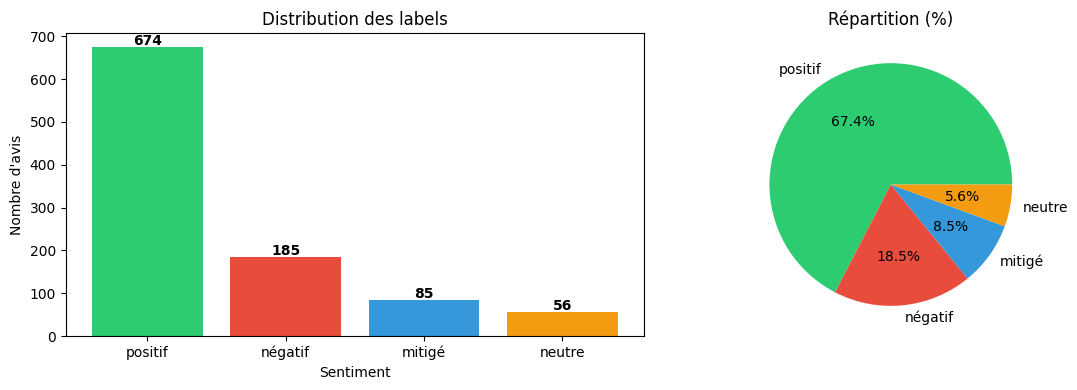

Figure sauvegardée : reports/label_distribution.png


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Barplot
counts = df['label'].value_counts()
axes[0].bar(counts.index, counts.values, color=['#2ecc71','#e74c3c','#3498db','#f39c12'])
axes[0].set_title('Distribution des labels')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Nombre d\'avis')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=['#2ecc71','#e74c3c','#3498db','#f39c12'])
axes[1].set_title('Répartition (%)')

plt.tight_layout()
plt.savefig('../reports/label_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figure sauvegardée : reports/label_distribution.png')

## 4. Encodage des labels & split train/test

In [27]:
# Encodage
le = LabelEncoder()
y = le.fit_transform(df['label'])
X_text = df['processed_avis'].values

print('Classes encodées :')
for i, cls in enumerate(le.classes_):
    print(f'  {i} → {cls}')

# Split stratifié 80/20
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f'\nTrain : {len(X_train_text)} avis')
print(f'Test  : {len(X_test_text)} avis')

Classes encodées :
  0 → mitigé
  1 → neutre
  2 → négatif
  3 → positif

Train : 800 avis
Test  : 200 avis


## 5. Vectorisation TF-IDF

In [28]:
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),   # unigrammes + bigrammes
    min_df=2,             # ignore les termes qui n'apparaissent qu'une fois
    max_df=0.90,          # ignore les termes trop fréquents
    max_features=5000,
    sublinear_tf=True,    # log(tf) — atténue les termes très fréquents
)

X_train = vectorizer.fit_transform(X_train_text)
X_test  = vectorizer.transform(X_test_text)

print(f'Vocabulaire TF-IDF : {len(vectorizer.vocabulary_)} termes')
print(f'Shape train : {X_train.shape}')
print(f'Shape test  : {X_test.shape}')

# Top 20 features
feature_names = vectorizer.get_feature_names_out()
print(f'\nExemples de features : {feature_names[:20].tolist()}')

Vocabulaire TF-IDF : 709 termes
Shape train : (800, 709)
Shape test  : (200, 709)

Exemples de features : ['abonne', 'absence', 'abîmer', 'accessible', 'accompagner', 'achat', 'achats', 'adapter', 'adapter besoins', 'adapter usage', 'adresse', 'adresse livraison', 'affiche', 'agent', 'agréable', 'agréable surpris', 'agréable utiliser', 'ai', 'ai dû', 'ai eu']


## 6. Entraînement et comparaison de 3 classifieurs

In [29]:
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, C=1.0, solver='lbfgs'
    ),
    'Naive Bayes': MultinomialNB(alpha=0.5),
    'LinearSVC (calibré)': CalibratedClassifierCV(
        LinearSVC(max_iter=2000, C=1.0)
    ),
}

results = {}

for name, clf in models.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc    = accuracy_score(y_test, y_pred)

    cv_scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy')

    results[name] = {
        'model':    clf,
        'accuracy': acc,
        'cv_mean':  cv_scores.mean(),
        'cv_std':   cv_scores.std(),
    }
    print(f'{name}')
    print(f'  Accuracy test   : {acc:.4f}')
    print(f'  CV (5-fold)     : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
    print()

Logistic Regression
  Accuracy test   : 0.6950
  CV (5-fold)     : 0.7362 ± 0.0108

Naive Bayes
  Accuracy test   : 0.7250
  CV (5-fold)     : 0.7850 ± 0.0242

LinearSVC (calibré)
  Accuracy test   : 0.7850
  CV (5-fold)     : 0.8000 ± 0.0240



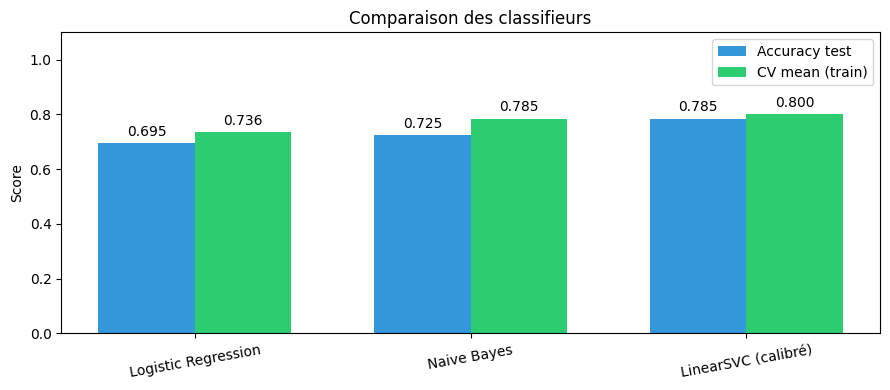

In [30]:
fig, ax = plt.subplots(figsize=(9, 4))
names    = list(results.keys())
accs     = [results[n]['accuracy'] for n in names]
cv_means = [results[n]['cv_mean']  for n in names]

x = np.arange(len(names))
width = 0.35
bars1 = ax.bar(x - width/2, accs,     width, label='Accuracy test', color='#3498db')
bars2 = ax.bar(x + width/2, cv_means, width, label='CV mean (train)', color='#2ecc71')

ax.set_ylabel('Score')
ax.set_title('Comparaison des classifieurs')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=10)
ax.set_ylim(0, 1.1)
ax.legend()
ax.bar_label(bars1, fmt='%.3f', padding=3)
ax.bar_label(bars2, fmt='%.3f', padding=3)

plt.tight_layout()
plt.savefig('../reports/model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Évaluation détaillée du meilleur modèle

In [31]:
best_name = max(results, key=lambda n: results[n]['accuracy'])
best_clf  = results[best_name]['model']
print(f'Meilleur modèle : {best_name}')
print(f'Accuracy test   : {results[best_name]["accuracy"]:.4f}')

Meilleur modèle : LinearSVC (calibré)
Accuracy test   : 0.7850


In [32]:
y_pred_best = best_clf.predict(X_test)

print('=== Rapport de classification ===')
print(classification_report(
    y_test, y_pred_best,
    target_names=le.classes_
))

=== Rapport de classification ===
              precision    recall  f1-score   support

      mitigé       0.57      0.24      0.33        17
      neutre       0.83      0.45      0.59        11
     négatif       0.57      0.62      0.60        37
     positif       0.85      0.93      0.89       135

    accuracy                           0.79       200
   macro avg       0.71      0.56      0.60       200
weighted avg       0.77      0.79      0.77       200



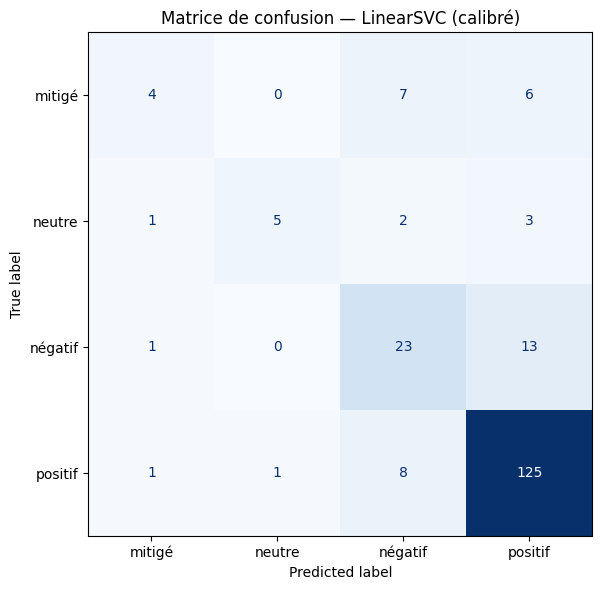

In [33]:
# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Matrice de confusion — {best_name}')
plt.tight_layout()
plt.savefig('../reports/confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. Features les plus importantes (Logistic Regression)

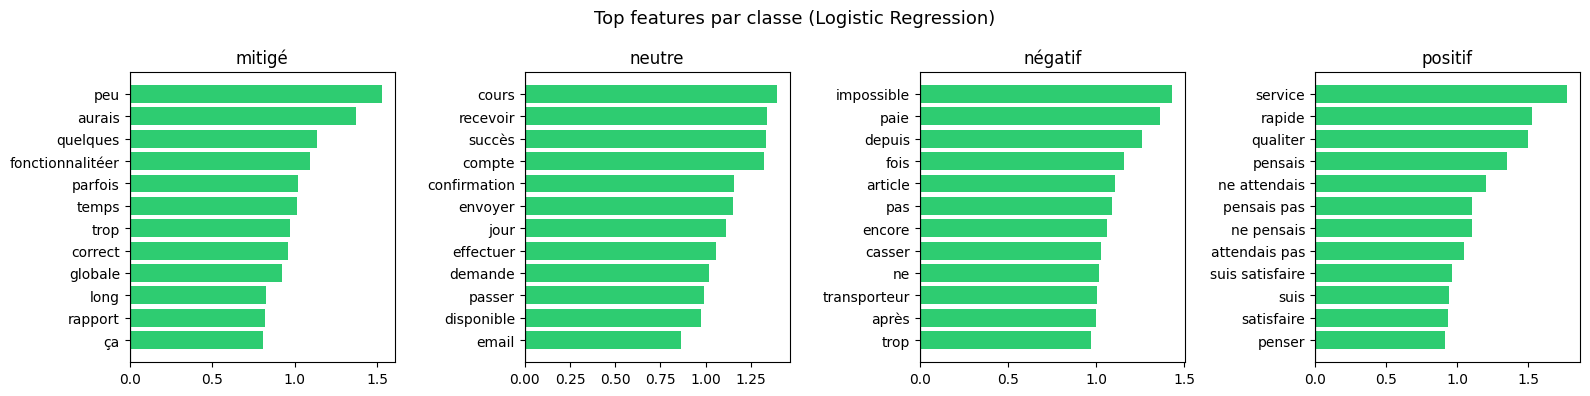

In [34]:
# Si le meilleur modèle est LR, on affiche les features les plus importantes
lr_clf = results['Logistic Regression']['model']

fig, axes = plt.subplots(1, len(le.classes_), figsize=(16, 4))

for i, (cls, ax) in enumerate(zip(le.classes_, axes)):
    coefs   = lr_clf.coef_[i]
    top_idx = np.argsort(coefs)[-12:][::-1]
    top_terms  = feature_names[top_idx]
    top_scores = coefs[top_idx]

    colors = ['#2ecc71' if s > 0 else '#e74c3c' for s in top_scores]
    ax.barh(top_terms[::-1], top_scores[::-1], color=colors[::-1])
    ax.set_title(f'{cls}')
    ax.axvline(0, color='black', linewidth=0.8)

fig.suptitle('Top features par classe (Logistic Regression)', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. Sauvegarde des artefacts

In [35]:
os.makedirs('../models', exist_ok=True)

joblib.dump(vectorizer, '../models/tfidf_vectorizer.joblib')
joblib.dump(le,         '../models/label_encoder.joblib')
joblib.dump(best_clf,   '../models/sentiment_classifier.joblib')

print('=== Artefacts sauvegardés ===')
for fname in ['tfidf_vectorizer.joblib', 'label_encoder.joblib', 'sentiment_classifier.joblib']:
    path = f'../models/{fname}'
    size = os.path.getsize(path)
    print(f'  {fname} — {size/1024:.1f} KB')

=== Artefacts sauvegardés ===
  tfidf_vectorizer.joblib — 28.4 KB
  label_encoder.joblib — 0.5 KB
  sentiment_classifier.joblib — 114.8 KB


## 10. Test rapide du modèle sauvegardé

In [36]:
# Rechargement depuis le disque pour vérifier
clf_loaded  = joblib.load('../models/sentiment_classifier.joblib')
vec_loaded  = joblib.load('../models/tfidf_vectorizer.joblib')
le_loaded   = joblib.load('../models/label_encoder.joblib')

test_avis = [
    ('service rapide professionnel',          'positif'),
    ('commande cassée déçu retard',           'négatif'),
    ('demande enregistrée',                   'neutre'),
    ('produit bon livraison longue',          'mitigé'),
]

print(f'{'Texte':<35} {'Attendu':<12} {'Prédit':<12} {'OK?'}')
print('-' * 65)
for text, expected in test_avis:
    X_demo  = vec_loaded.transform([text])
    pred_i  = clf_loaded.predict(X_demo)[0]
    pred    = le_loaded.inverse_transform([pred_i])[0]
    ok      = '✅' if pred == expected else '❌'
    print(f'{text:<35} {expected:<12} {pred:<12} {ok}')

Texte                               Attendu      Prédit       OK?
-----------------------------------------------------------------
service rapide professionnel        positif      positif      ✅
commande cassée déçu retard         négatif      négatif      ✅
demande enregistrée                 neutre       neutre       ✅
produit bon livraison longue        mitigé       positif      ❌


## ✅ Notebook terminé

Les trois fichiers suivants sont prêts dans `models/` :
- `tfidf_vectorizer.joblib`
- `label_encoder.joblib`
- `sentiment_classifier.joblib`

Vous pouvez maintenant lancer `streamlit run app.py`.
Le module `src/ml_classifier.py` chargera ces artefacts automatiquement.